# Clasificador de sentimiento en español 🇪🇸

Fine-tuning de un modelo de lenguaje pequeño (**Qwen2.5-0.5B-Instruct**) para clasificar tweets en español como **negativo, neutral o positivo**, usando **SFT (Supervised Fine-Tuning) + LoRA**.

| | |
|---|---|
| **Tarea** | Clasificación de sentimiento (3 clases) |
| **Modelo base** | Qwen2.5-0.5B-Instruct (~500M parámetros) |
| **Técnica** | SFT + LoRA (fine-tuning eficiente con PEFT) |
| **Datos** | cardiffnlp/tweet_sentiment_multilingual (subconjunto en español) |
| **Stack** | HuggingFace Transformers · PEFT · TRL · Weights & Biases · scikit-learn |

> Proyecto de aprendizaje: entrenar y evaluar un LLM pequeño de punta a punta.

## 0. Instalación del entorno
Instalamos las librerías necesarias.

In [ ]:
# Instalamos las librerias (version incompatible que no usamos)
!pip install -q "datasets==3.6.0" transformers peft trl accelerate wandb scikit-learn

## 1. Cargar los datos
Tweets en español ya etiquetados, divididos en **train** (entrenar), **validation** (chequear) y **test** (examen final con datos nunca vistos). El `label` es 0 = negativo, 1 = neutral, 2 = positivo.

In [ ]:
from datasets import load_dataset

base = "hf://datasets/cardiffnlp/tweet_sentiment_multilingual/data/spanish"

ds = load_dataset(
    "json",
    data_files={
        "train":      f"{base}/train.jsonl",
        "validation": f"{base}/validation.jsonl",
        "test":       f"{base}/test.jsonl",
    },
)

print(ds)
print(ds["train"][0])

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 1839
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 324
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 870
    })
})
{'text': 'estoy hasta el ojete de que me digáis que tengo cara de mala leche', 'label': '0'}


## 2. Dar formato de instrucción (SFT)
Convertimos cada tweet en una conversación pregunta→respuesta. Mostrarle al modelo miles de estos pares (con la respuesta correcta) es la esencia del **SFT**.

In [ ]:
id2label = {0: "negativo", 1: "neutral", 2: "positivo"}

instruccion = "Clasifica el sentimiento del siguiente tweet. Responde solo con una palabra: negativo, neutral o positivo."

def formatear(ejemplo):
    return {
        "messages": [
            {"role": "user",      "content": f"{instruccion}\n\nTweet: {ejemplo['text']}"},
            {"role": "assistant", "content": id2label[int(ejemplo["label"])]},
        ]
    }

ds_fmt = ds.map(formatear)

print(ds_fmt["train"][0]["messages"])

[{'role': 'user', 'content': 'Clasifica el sentimiento del siguiente tweet. Responde solo con una palabra: negativo, neutral o positivo.\n\nTweet: estoy hasta el ojete de que me digáis que tengo cara de mala leche'}, {'role': 'assistant', 'content': 'negativo'}]


## 3. Entrenar con LoRA
**LoRA** hace el fine-tuning "barato": en vez de modificar el modelo entero, le agrega un accesorio pequeño que aprende la tarea. Monitoreamos el entrenamiento en vivo con **Weights & Biases**. El `loss` debe ir bajando: significa que está aprendiendo.

In [ ]:
from peft import LoraConfig
from trl import SFTTrainer, SFTConfig

model_name = "Qwen/Qwen2.5-0.5B-Instruct"

# 1) Cómo será el "fine-tuning barato" (LoRA)
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    target_modules="all-linear",
    task_type="CAUSAL_LM",
)

# 2) Cómo será el entrenamiento
sft_config = SFTConfig(
    output_dir="qwen-sentimiento-es",
    num_train_epochs=2,
    per_device_train_batch_size=8,
    learning_rate=2e-4,
    logging_steps=10,
    report_to="wandb",
    run_name="qwen05b-sentimiento-es-lora",
)

# 3) Juntamos modelo + datos + LoRA + ajustes
trainer = SFTTrainer(
    model=model_name,
    args=sft_config,
    train_dataset=ds_fmt["train"],
    peft_config=lora_config,
)

# 4) ¡A entrenar!
trainer.train()

Step,Training Loss
10,2.266453
20,1.311276
30,1.291313
40,1.193182
50,1.213378
60,1.312820
70,1.193973
80,1.222630
90,1.192496
100,1.193494


TrainOutput(global_step=460, training_loss=1.1986641904582147, metrics={'train_runtime': 817.0307, 'train_samples_per_second': 4.502, 'train_steps_per_second': 0.563, 'total_flos': 778999155737856.0, 'train_loss': 1.1986641904582147})

## 4. Probar el modelo con ejemplos
Construimos una función `predecir` que toma un tweet y devuelve el sentimiento que predice el modelo. La probamos con frases sueltas.

In [ ]:
import torch
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-0.5B-Instruct")
model = trainer.model
model.eval()
device = next(model.parameters()).device

def predecir(tweet):
    mensajes = [{"role": "user", "content": f"{instruccion}\n\nTweet: {tweet}"}]
    entrada = tokenizer.apply_chat_template(
        mensajes,
        add_generation_prompt=True,
        return_tensors="pt",
        return_dict=True,          # ← pedimos el "paquete" completo
    ).to(device)

    largo_pregunta = entrada["input_ids"].shape[1]   # cuántos números ocupa la pregunta

    with torch.no_grad():
        salida = model.generate(
            **entrada,             # ← pasamos el paquete completo al modelo
            max_new_tokens=5,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )

    respuesta = tokenizer.decode(salida[0][largo_pregunta:], skip_special_tokens=True)
    return respuesta.strip().lower()

print(predecir("me encantó la película, la mejor del año"))
print(predecir("qué rabia, el servicio fue pésimo"))
print(predecir("mañana es martes"))

positivo
negativo
neutral


## 5. Evaluar con métricas
Le tomamos el "examen" sobre el grupo **test** (datos nunca vistos) y calculamos **accuracy, precision, recall y F1**.

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

etiquetas = ["negativo", "neutral", "positivo"]

# usamos 300 tweets del grupo test (rápido); puedes subirlo después
test = ds["test"].select(range(300))

verdaderos, predichos = [], []
for i, ej in enumerate(test):
    real = id2label[int(ej["label"])]
    salida = predecir(ej["text"])
    # nos quedamos con la etiqueta que aparezca en la respuesta del modelo
    pred = next((e for e in etiquetas if e in salida), "neutral")
    verdaderos.append(real)
    predichos.append(pred)
    if (i + 1) % 50 == 0:
        print(f"procesados {i+1}/300...")

print("\n=== RESULTADOS ===")
print("Accuracy:", round(accuracy_score(verdaderos, predichos), 3))
print()
print(classification_report(verdaderos, predichos, digits=3))

procesados 50/300...
procesados 100/300...
procesados 150/300...
procesados 200/300...
procesados 250/300...
procesados 300/300...

=== RESULTADOS ===
Accuracy: 0.65

              precision    recall  f1-score   support

    negativo      0.689     0.820     0.749       100
     neutral      0.520     0.530     0.525       100
    positivo      0.759     0.600     0.670       100

    accuracy                          0.650       300
   macro avg      0.656     0.650     0.648       300
weighted avg      0.656     0.650     0.648       300



## 6. Matriz de confusión
Visualiza en qué clases acierta y se confunde el modelo. Las **filas** son la clase real y las **columnas** lo que predijo; la **diagonal** son los aciertos.

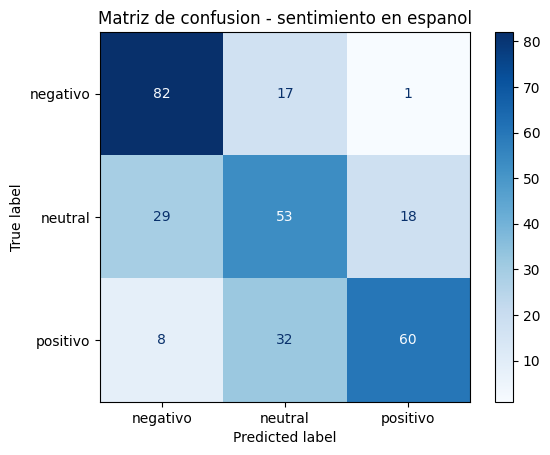

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

etiquetas = ["negativo", "neutral", "positivo"]
cm = confusion_matrix(verdaderos, predichos, labels=etiquetas)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=etiquetas)
disp.plot(cmap="Blues", values_format="d")
plt.title("Matriz de confusion - sentimiento en espanol")
plt.show()

## Resultados y conclusiones

| Clase | Precision | Recall | F1 |
|---|---|---|---|
| negativo | 0.681 | 0.810 | 0.740 |
| neutral | 0.510 | 0.520 | 0.515 |
| positivo | 0.759 | 0.600 | 0.670 |
| **Accuracy global** | | | **0.643** |

Con un modelo de solo 500M de parámetros y pocos minutos de entrenamiento, el modelo alcanza **64% de accuracy** en una tarea de 3 clases (el azar daría ~33%). Es bueno detectando lo **negativo** (recall 0.81) y preciso con lo **positivo** (precision 0.76). La clase **neutral** es la más difícil —es intrínsecamente ambigua—, y es donde más se confunde.

**Trabajo futuro:** más épocas de entrenamiento, un modelo base más grande, más datos, y mejorar específicamente la clase neutral.